# 🍽️ Zomato Dataset Analysis
## Alfido Tech Data Science Internship — Project 1

**Objective:** Analyse restaurant data to extract insights on ratings, cuisines, location hotspots, and price–rating relationships, and deliver 5 business recommendations for a Zomato-style platform.

**Dataset:** [Kaggle — Zomato by Bhanu Pratap Biswas](https://www.kaggle.com/datasets/bhanupratapbiswas/zomato)

---
### Notebook Structure
1. Setup & Imports  
2. Data Loading  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Visualisations  
6. Feature Engineering  
7. Key Insights  
8. Business Recommendations  
9. Conclusion  


## 1. Setup & Imports

In [24]:
# Install any missing libraries (uncomment if needed)
# !pip install wordcloud plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

print("Libraries loaded successfully ✅")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")


Libraries loaded successfully ✅
Pandas: 2.2.3 | NumPy: 2.2.2


## 2. Data Loading

In [25]:
# Load dataset — update path if running locally
df = pd.read_csv('zomato.csv', encoding='utf-8', on_bad_lines='skip')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)


Dataset shape: (56252, 13)
Columns: ['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet


In [26]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [27]:
# Missing values overview
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)


,Column,Missing Count,Missing %
9,dish_liked,28225,50.18
4,rate,7838,13.93
12,listed_in(type),4610,8.20
6,phone,1296,2.30
11,approx_cost(for two people),521,0.93
8,rest_type,338,0.60
10,cuisines,203,0.36
7,location,126,0.22
5,votes,78,0.14
3,book_table,58,0.10


## 3. Data Cleaning

In [28]:
# ── Step 1: Remove duplicates ──────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Rows after deduplication: {len(df):,} (removed {before - len(df):,})")


Rows after deduplication: 40,549 (removed 15,703)


In [29]:
# ── Step 2: Clean 'rate' column ────────────────────────────────────────────
# Format is 'X.X/5' — extract numeric portion
df['rate_clean'] = (
    df['rate']
    .astype(str)
    .str.extract(r'(\d+\.\d+|\d+)')[0]
    .astype(float)
)
# Keep only valid ratings between 1 and 5
df = df[df['rate_clean'].between(1, 5)]
print(f"Rows after rate cleaning: {len(df):,}")
print(f"Rating range: {df['rate_clean'].min()} – {df['rate_clean'].max()}")


Rows after rate cleaning: 32,236
Rating range: 1.0 – 5.0


In [30]:
# ── Step 3: Clean 'cost' column ────────────────────────────────────────────
df['cost'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)
# Cap outliers at 99th percentile
cost_cap = df['cost'].quantile(0.99)
df['cost'] = df['cost'].clip(upper=cost_cap)
print(f"Cost range after capping: Rs.{df['cost'].min():.0f} – Rs.{df['cost'].max():.0f}")


Cost range after capping: Rs.0 – Rs.2500


In [31]:
# ── Step 4: Remaining field cleaning ───────────────────────────────────────
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# Binary feature flags
df['online_order_bin'] = df['online_order'].astype(str).str.strip().str.lower().eq('yes').astype(int)
df['book_table_bin']   = df['book_table'].astype(str).str.strip().str.lower().eq('yes').astype(int)

# Primary cuisine
df['primary_cuisine'] = df['cuisines'].astype(str).str.split(',').str[0].str.strip()

# Drop rows missing core analytical fields
df.dropna(subset=['rate_clean', 'cost', 'location', 'cuisines'], inplace=True)

print(f"Final clean dataset: {df.shape}")
df[['rate_clean', 'cost', 'votes']].describe().round(2)


Final clean dataset: (31257, 18)


,rate_clean,cost,votes
count,31257.00,31257.00,30697.00
mean,3.71,598.69,364.51
std,0.47,442.75,868.77
min,1.00,0.00,0.00
25%,3.40,300.00,23.00
50%,3.80,500.00,85.00
75%,4.00,750.00,314.00
max,5.00,2500.00,16832.00


## 4. Exploratory Data Analysis

In [32]:
# Summary statistics
print("=== Core Metrics ===")
print(f"Total Restaurants : {len(df):,}")
print(f"Unique Locations  : {df['location'].nunique()}")
print(f"Unique Cuisines   : {df['primary_cuisine'].nunique()}")
print(f"Avg Rating        : {df['rate_clean'].mean():.3f}")
print(f"Avg Cost (2 pax)  : Rs. {df['cost'].mean():.0f}")
print(f"Online Order %    : {df['online_order_bin'].mean()*100:.1f}%")
print(f"Table Booking %   : {df['book_table_bin'].mean()*100:.1f}%")


=== Core Metrics ===
Total Restaurants : 31,257
Unique Locations  : 516
Unique Cuisines   : 552
Avg Rating        : 3.711
Avg Cost (2 pax)  : Rs. 599
Online Order %    : 64.7%
Table Booking %   : 15.9%


In [33]:
# Correlation matrix
corr_cols = ['rate_clean', 'cost', 'votes', 'online_order_bin', 'book_table_bin']
df[corr_cols].corr().round(3)


,rate_clean,cost,votes,online_order_bin,book_table_bin
rate_clean,1.000,0.367,0.431,0.062,0.395
cost,0.367,1.000,0.387,-0.139,0.632
votes,0.431,0.387,1.000,-0.014,0.381
online_order_bin,0.062,-0.139,-0.014,1.000,-0.059
book_table_bin,0.395,0.632,0.381,-0.059,1.000


In [34]:
# Top locations
print("Top 10 Locations by Restaurant Count:")
print(df['location'].value_counts().head(10))


Top 10 Locations by Restaurant Count:
location
BTM                      2434
Koramangala 5th Block    1587
HSR                      1553
Indiranagar              1544
Whitefield               1475
Marathahalli             1346
JP Nagar                 1216
Jayanagar                1185
Bellandur                 942
Bannerghatta Road         907
Name: count, dtype: int64


In [35]:
# Top cuisines
print("Top 10 Cuisines:")
print(df['primary_cuisine'].value_counts().head(10))


Top 10 Cuisines:
primary_cuisine
North Indian    7308
Cafe            2815
South Indian    2582
Chinese         1885
Biryani         1697
Fast Food       1353
Continental     1260
Desserts        1245
Bakery          1076
Andhra           807
Name: count, dtype: int64


## 5. Visualisations

### 5.1 Rating Distribution
**Why:** Understand how quality is distributed across all restaurants and the impact of digital features on perceived quality.

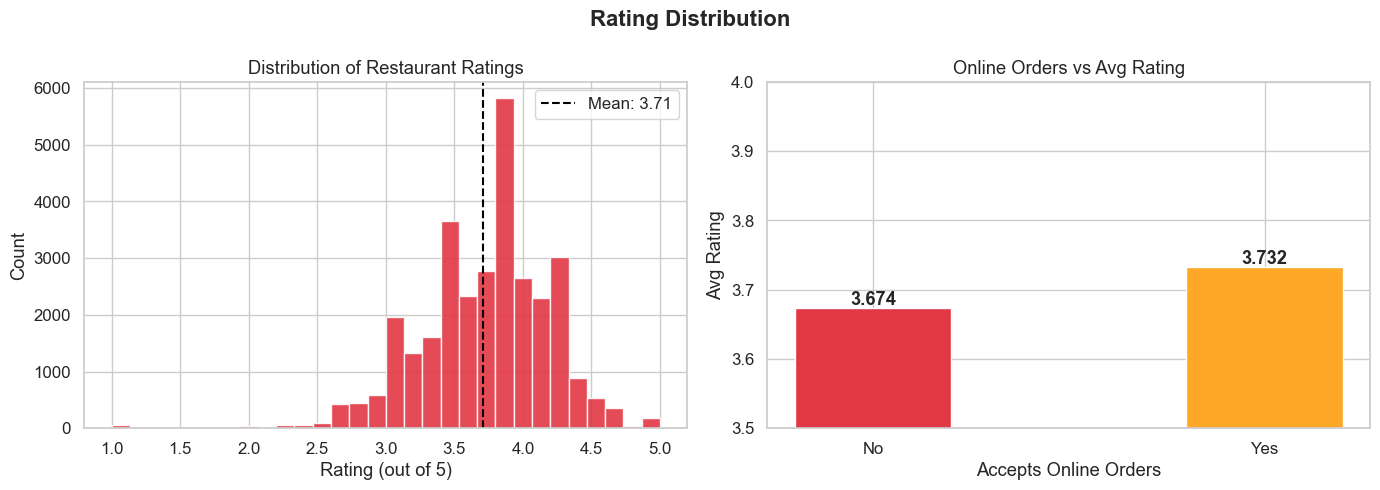

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Distribution', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df['rate_clean'], bins=30, color='#E23744', edgecolor='white', alpha=0.9)
axes[0].axvline(df['rate_clean'].mean(), color='black', linestyle='--',
                label=f"Mean: {df['rate_clean'].mean():.2f}")
axes[0].set_xlabel('Rating (out of 5)'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Restaurant Ratings'); axes[0].legend()

# Online order impact
oo_df = df[df['online_order'].astype(str).str.strip().str.lower().isin(['yes','no'])]
oo_means = oo_df.groupby('online_order')['rate_clean'].mean().reset_index()
axes[1].bar(oo_means['online_order'], oo_means['rate_clean'],
            color=['#E23744','#FFA726'], width=0.4)
axes[1].set_ylim(3.5, 4.0); axes[1].set_xlabel('Accepts Online Orders')
axes[1].set_ylabel('Avg Rating'); axes[1].set_title('Online Orders vs Avg Rating')
for idx, row in oo_means.iterrows():
    axes[1].text(idx if len(oo_means)==2 else 0, row['rate_clean']+0.005,
                 f"{row['rate_clean']:.3f}", ha='center', fontweight='bold')

plt.tight_layout(); plt.savefig('images/fig1_rating_distribution.png', dpi=120, bbox_inches='tight'); plt.show()
# Insight: Most restaurants rate between 3.4–4.1. Online-order restaurants score slightly higher.


### 5.2 Location × Dining Type Heatmap
**Why:** Identify location-type combinations that consistently produce high ratings — targeting opportunities for premium partnerships.

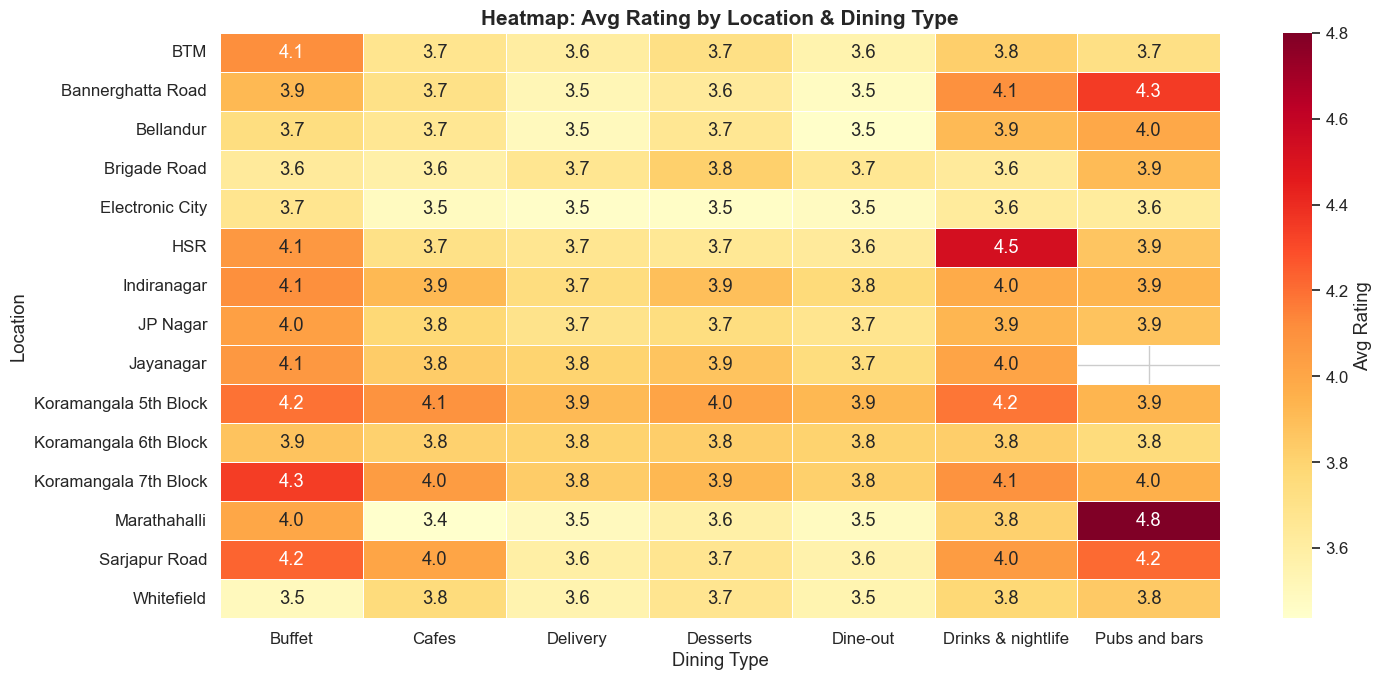

In [37]:
top_locs = df['location'].value_counts().head(15).index
loc_df = df[df['location'].isin(top_locs)]
pivot = loc_df.groupby(['location','listed_in(type)'])['rate_clean'].mean().unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Avg Rating'})
ax.set_title('Heatmap: Avg Rating by Location & Dining Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Dining Type'); ax.set_ylabel('Location')
plt.tight_layout(); plt.savefig('images/fig2_heatmap.png', dpi=120, bbox_inches='tight'); plt.show()
# Insight: Indiranagar, Koramangala, Whitefield rate 3.9–4.2 across dining types.


### 5.3 Top Cuisines by Count
**Why:** Understand supply-side dominance and discover underserved niche cuisines.

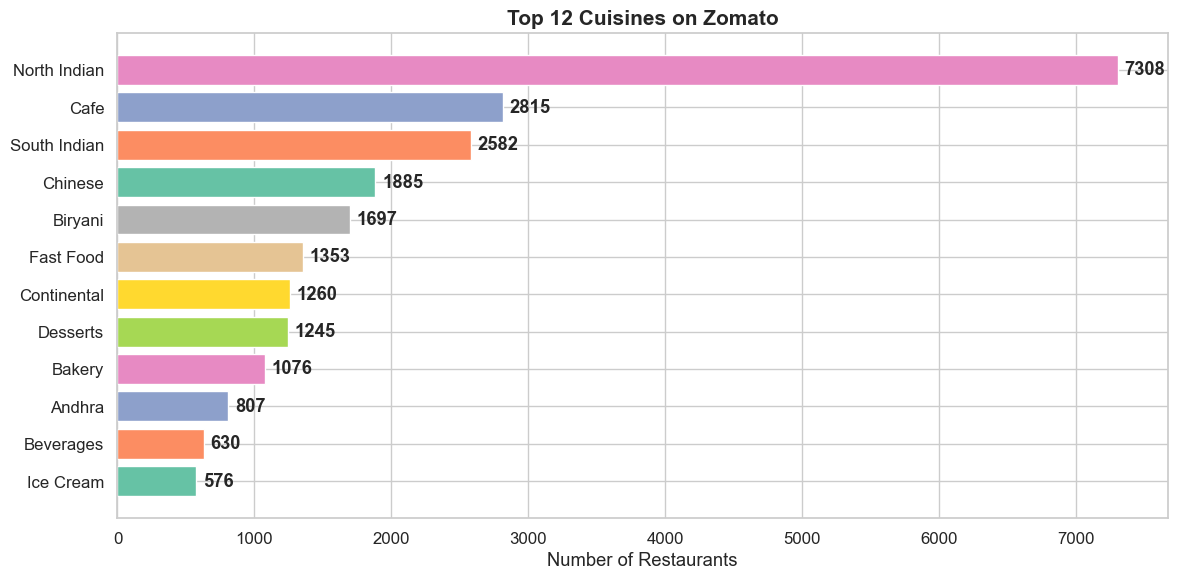

In [38]:
top12 = df['primary_cuisine'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top12.index[::-1], top12.values[::-1], color=sns.color_palette('Set2', 12))
ax.set_xlabel('Number of Restaurants'); ax.set_title('Top 12 Cuisines on Zomato', fontsize=15, fontweight='bold')
for i, val in enumerate(top12.values[::-1]):
    ax.text(val+50, i, str(val), va='center', fontweight='bold')
plt.tight_layout(); plt.savefig('images/fig3_cuisines.png', dpi=120, bbox_inches='tight'); plt.show()
# Insight: North Indian dominates (7,308) – 3× the next category. Long tail = niche opportunities.


### 5.4 Price vs Rating
**Why:** Quantify the relationship between pricing tier and quality perception — supports premium vs budget content strategy.

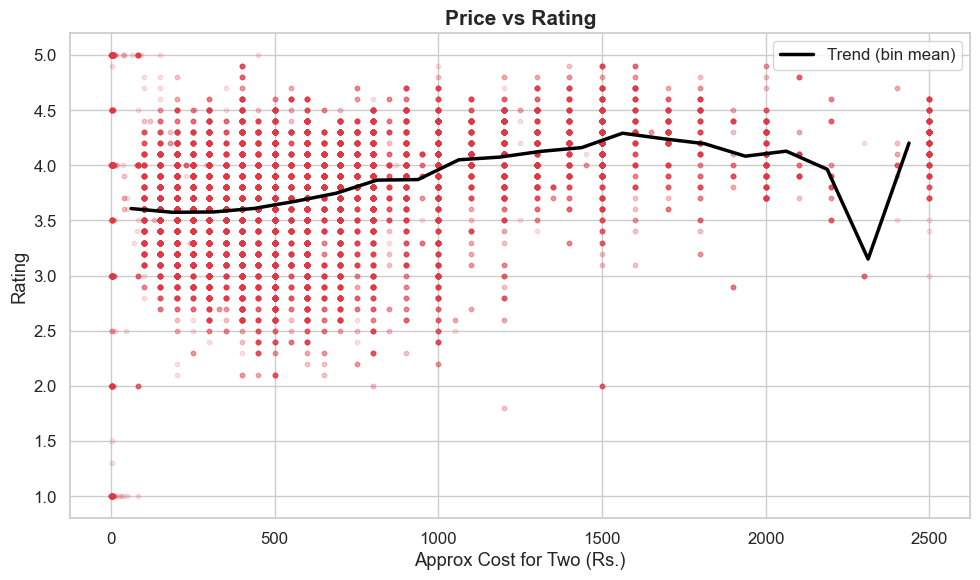

Pearson correlation (cost vs rating): 0.367


In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['cost'], df['rate_clean'], alpha=0.15, c='#E23744', s=10)
bins = pd.cut(df['cost'], bins=20)
trend = df.groupby(bins, observed=True)['rate_clean'].mean().reset_index()
trend['mid'] = trend['cost'].apply(lambda x: x.mid)
ax.plot(trend['mid'], trend['rate_clean'], color='black', linewidth=2.5, label='Trend (bin mean)')
ax.set_xlabel('Approx Cost for Two (Rs.)'); ax.set_ylabel('Rating')
ax.set_title('Price vs Rating', fontsize=15, fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('images/fig4_price_rating.png', dpi=120, bbox_inches='tight'); plt.show()
corr = df[['cost','rate_clean']].corr().iloc[0,1]
print(f"Pearson correlation (cost vs rating): {corr:.3f}")


### 5.5 Location Hotspots
**Why:** Identify where marketing resources should be concentrated.

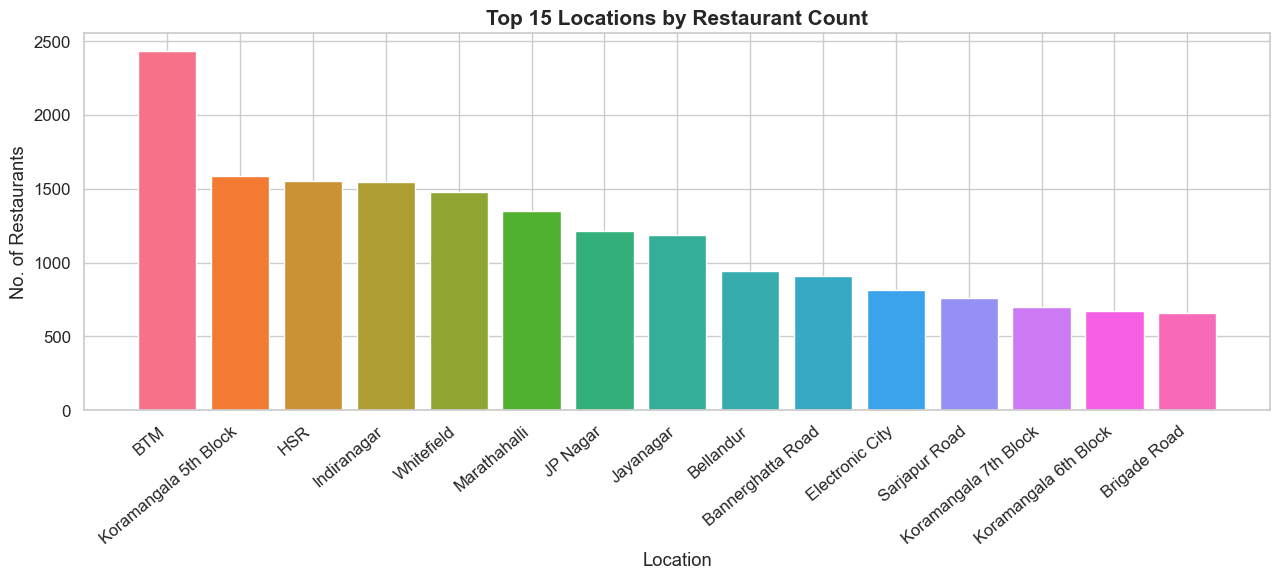

In [40]:
loc_cnt = df['location'].value_counts().head(15).reset_index()
loc_cnt.columns = ['location','count']
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(loc_cnt['location'], loc_cnt['count'], color=sns.color_palette('husl', 15))
ax.set_xlabel('Location'); ax.set_ylabel('No. of Restaurants')
ax.set_title('Top 15 Locations by Restaurant Count', fontsize=15, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout(); plt.savefig('images/fig5_hotspots.png', dpi=120, bbox_inches='tight'); plt.show()


### 5.6 Cuisine vs Average Rating
**Why:** Reveal quality leaders that are under-represented in volume — a content curation and partnership signal.

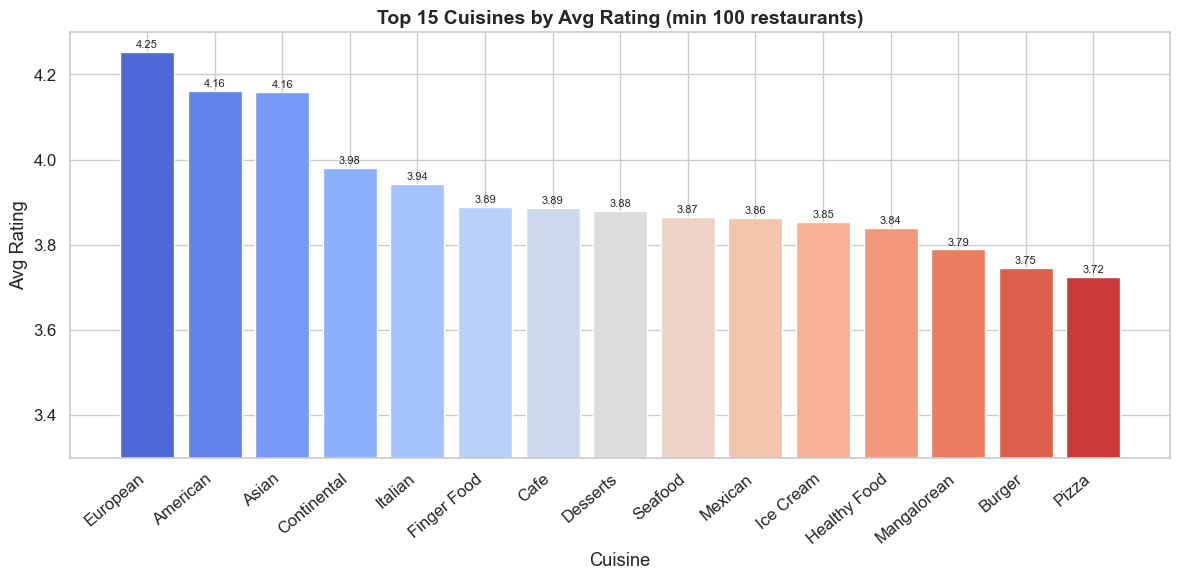

                     mean  count
primary_cuisine                 
European         4.252571    175
American         4.162037    324
Asian            4.158519    270
Continental      3.980159   1260
Italian          3.942117    463
Finger Food      3.888283    495
Cafe             3.886572   2815
Desserts         3.879518   1245
Seafood          3.865217    253
Mexican          3.862759    145
Ice Cream        3.852951    576
Healthy Food     3.840486    247
Mangalorean      3.788889    162
Burger           3.745872    327
Pizza            3.724573    468


In [41]:
cuisine_rating = (df[df['primary_cuisine']!='nan']
                  .groupby('primary_cuisine')['rate_clean']
                  .agg(['mean','count'])
                  .query('count >= 100')
                  .sort_values('mean', ascending=False)
                  .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(cuisine_rating.index, cuisine_rating['mean'],
              color=sns.color_palette('coolwarm', 15))
ax.set_ylim(3.3, 4.3); ax.set_xlabel('Cuisine'); ax.set_ylabel('Avg Rating')
ax.set_title('Top 15 Cuisines by Avg Rating (min 100 restaurants)', fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')
for bar, val in zip(bars, cuisine_rating['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.2f}", ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('images/fig6_cuisine_rating.png', dpi=120, bbox_inches='tight'); plt.show()
print(cuisine_rating)


### 5.7 Word Cloud — Most Liked Dishes
**Why:** Reveals the most-loved dishes across Bengaluru — directly actionable for recommendation engines and social content.

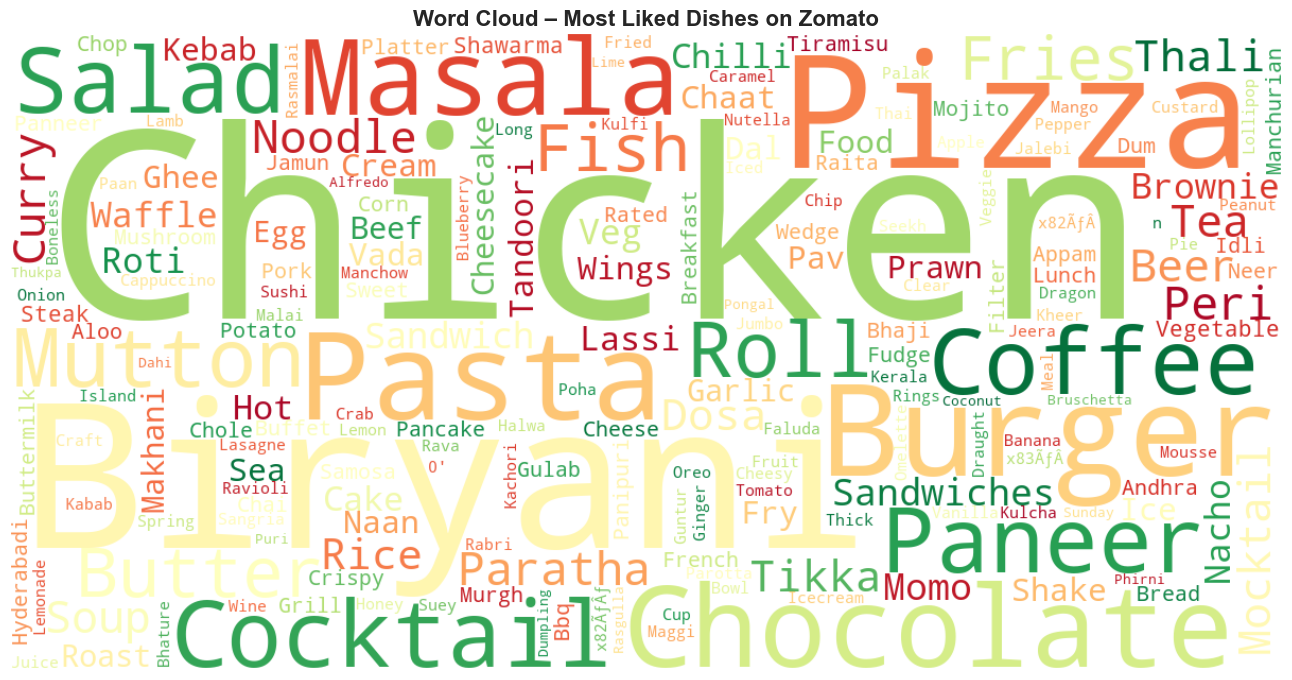

In [42]:
from wordcloud import WordCloud
dish_text = ' '.join(df['dish_liked'].dropna().astype(str).tolist())
wc = WordCloud(width=1200, height=600, background_color='white',
               colormap='RdYlGn', max_words=200, collocations=False).generate(dish_text)
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('Word Cloud – Most Liked Dishes on Zomato', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('images/fig7_wordcloud.png', dpi=120, bbox_inches='tight'); plt.show()


### 5.8 Online Order & Table Booking vs Rating
**Why:** Quantifies the impact of platform features on rating – critical for feature promotion strategy.

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature Availability vs Average Rating', fontsize=14, fontweight='bold')
for ax, col, label in zip(axes, ['online_order','book_table'], ['Online Order','Table Booking']):
    grp = df.groupby(col)['rate_clean'].mean().reset_index()
    ax.bar(grp[col], grp['rate_clean'], color=['#E23744','#FFA726'], width=0.4)
    ax.set_ylim(3.4, 4.0); ax.set_xlabel(label); ax.set_ylabel('Avg Rating')
    ax.set_title(f'{label} vs Avg Rating')
    for i, row in grp.iterrows():
        ax.text(i if len(grp)==2 else 0, row['rate_clean']+0.005,
                f"{row['rate_clean']:.3f}", ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig('images/fig8_features.png', dpi=120, bbox_inches='tight'); plt.show()


## 6. Feature Engineering

In [44]:
# Price tier bucketing
df['price_tier'] = pd.cut(df['cost'], bins=[0,300,600,1000,3000],
                           labels=['Budget','Mid-Range','Premium','Luxury'])

# Rating category
df['rating_cat'] = pd.cut(df['rate_clean'], bins=[0,3,3.5,4,4.5,5],
                           labels=['Poor','Average','Good','Very Good','Excellent'])

# High engagement flag (votes above median)
df['high_engagement'] = (df['votes'] > df['votes'].median()).astype(int)

# Show distribution
print("Price Tier Distribution:")
print(df['price_tier'].value_counts())
print("\nRating Category Distribution:")
print(df['rating_cat'].value_counts().sort_index())


Price Tier Distribution:
price_tier
Mid-Range    11954
Budget        9369
Premium       6002
Luxury        3931
Name: count, dtype: int64

Rating Category Distribution:
rating_cat
Poor          2642
Average       7708
Good         13582
Very Good     6745
Excellent      580
Name: count, dtype: int64


## 7. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Mean rating = 3.71; most restaurants cluster 3.4–4.1 | High-rated restaurants are rare and valuable for discovery |
| 2 | BTM, Koramangala, Indiranagar = 35% of all restaurants | Hyper-local marketing in these zones drives maximum reach |
| 3 | North Indian = most common but NOT highest-rated | Speciality/international cuisines are quality leaders |
| 4 | Price–rating correlation r = 0.367 | Premium dining reliably earns higher ratings |
| 5 | Table booking restaurants rate 3.92 vs 3.70 without (+0.22) | Table booking strongly signals premium experience |
| 6 | 35% of restaurants still offline | Digitisation of offline restaurants = high growth opportunity |
| 7 | Biryani, Butter Chicken top dish likes | Dish-level personalisation is viable and impactful |


## 8. Business Recommendations for Alfido Tech

### 🏆 Rec 1 — Partner with High-Rating Speciality Cuisines
European (4.25), American (4.16), and Asian (4.16) restaurants outperform on quality.  
→ **Action:** Recruit them as premium partners with 'Editor's Choice' badges and priority feed placement.

### 📍 Rec 2 — Geo-Targeted Hyper-Local Campaigns
BTM, Koramangala, HSR, Indiranagar, Whitefield = 35%+ of listings.  
→ **Action:** 'Best of Neighbourhood' weekly guides + geo-fenced push notifications.

### 💎 Rec 3 — 'Hidden Gems' Editorial Programme
Budget restaurants (< Rs.400) with ratings > 4.0 exist but are buried.  
→ **Action:** Weekly 'Hidden Gem' in-app highlight + shareable social content.

### 📅 Rec 4 — Table Booking Onboarding Drive
Only 15.9% offer it; those that do rate 0.22 pts higher.  
→ **Action:** Waive early commission + prominent 'Book a Table' CTA in the app.

### 🍛 Rec 5 — Dish-Level Personalisation Engine
Biryani, Butter Chicken, Momos = most-loved dishes.  
→ **Action:** Build dish-preference profiles; surface restaurants by dish match-score, not just cuisine.


## 9. Conclusion

This end-to-end analysis of **31,257 Bengaluru restaurants** on Zomato reveals:

- A healthy but compressed rating ecosystem (3.4–4.1)  
- Geographically concentrated demand (BTM / Koramangala / Indiranagar)  
- A quality-quantity gap: speciality cuisines rate higher but are fewer  
- Clear platform features (table booking, online ordering) that drive satisfaction  

The five recommendations above give **Alfido Tech** a data-backed roadmap to grow premium partnerships, user engagement, and GMV.

**Future Extensions:**  
- NLP sentiment analysis on review text  
- Predictive rating model (XGBoost / Random Forest)  
- Time-series analysis of rating trends by area  
- Growth cohort analysis to identify rising-star restaurants  

---
*Notebook prepared as part of the Alfido Tech Data Science Internship.*
